# Context Offloading & Virtual File System

**Context Offloading** 기법을 활용하여 에이전트의 컨텍스트 윈도우를 효율적으로 관리하고, 가상 파일 시스템을 구축하는 방법을 다룹니다.

*   **Context Offloading**: 파일 시스템을 활용한 효율적인 컨텍스트 관리 전략
*   **Virtual File System**: LangGraph State 내 가상 파일 시스템 설계 및 구현
*   **File Tools**: `ls`, `read_file`, `write_file` 도구 개발 및 프롬프트 설계
*   **State & Reducer**: 파일 시스템 통합 및 Reducer를 통한 상태 병합 원리
*   **실습**: 연구 에이전트 예제를 통한 Context Offloading 적용

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

---

## Filesystem 을 활용한 Context Offloading

**Context Offloading**은 복잡한 작업 시 급격히 증가하는 Context Window 문제를 해결하기 위해, 중요 정보를 파일 시스템에 저장하고 필요 시 로드하는 전략입니다.

*   **필요성**: 다수의 Tool 호출로 인한 Context 누적 및 비용 증가 방지
*   **활용 사례**:
    *   [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus): 메모리 관리 최적화
    *   [Hugging Face Open Deep Research](https://huggingface.co/blog/open-deep-research): 대규모 연구 작업 지원
    *   [Anthropic Multi-agent System](https://www.anthropic.com/engineering/multi-agent-research-system): Subagent 간 정보 왜곡 방지 및 효율적 정보 공유
*   **장점**:
    *   메모리 효율성 증대
    *   구조화된 결과물(코드, 보고서 등)의 안정적 보존
    *   장기 작업 시 중간 결과 유지 및 재활용 용이

---

## State & Reducer 정의

In [3]:
from state import DeepAgentState

FileSystemDeepAgentState = DeepAgentState
??FileSystemDeepAgentState

Init signature: FileSystemDeepAgentState(self, /, *args, **kwargs)
Source:        
class DeepAgentState(AgentState):
    """작업 추적 및 가상 파일 시스템을 포함하는 확장된 에이전트 상태.

    LangGraph의 AgentState를 상속하며 다음을 추가:
    - todos: 작업 계획 및 진행 상황 추적을 위한 Todo 항목 리스트
    - files: 파일명을 내용에 매핑하는 딕셔너리 형태의 가상 파일 시스템

    Notes:
        - todos는 전체 덮어쓰기 방식으로 업데이트
        - files는 file_reducer로 병합 (새로운/업데이트된 파일들 (오른쪽 딕셔너리 우선))
    """

    todos: NotRequired[list[TodoContent]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]
File:           ~/Desktop/personal/deep_research_with_deepagents/01_deep_agents/state.py
Type:           _TypedDictMeta
Subclasses:     

In [5]:
from prompts import FILE_USAGE_INSTRUCTIONS, SIMPLE_RESEARCH_INSTRUCTIONS

SYSTEM_INSTRUCTIONS = (
    FILE_USAGE_INSTRUCTIONS + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_INSTRUCTIONS
)

---

## 샘플 연구 에이전트(Research Agent)

가상 파일 시스템과 도구를 활용하여 **Context Offloading**을 적용한 연구 에이전트(Research Agent)를 생성합니다.

*   **시나리오**: 사용자 요청 저장 → 파일 읽기 → 답변 생성
*   **활용성**:
    *   **Long-running Agent**: 장기 작업 시 중요 정보 보존
    *   **Context Engineering**: 정보 압축 및 삭제 대비 중요 데이터 백업
*   **참고**: [Anthropic Multi-agent System](https://www.anthropic.com/engineering/multi-agent-research-system)의 파일 기반 Context Engineering

- `Annotated[DeepAgentState, InjectedState]`: LangGraph의 state injection 패턴을 사용하여 자동으로 state를 주입받습니다.
- `list[str]`: 파일명들의 리스트를 반환합니다.

### 초기 상태 및 실행 흐름

*   **초기 상태**: 빈 `files` 상태로 시작
*   **실행 흐름**: 사용자 요청 수신 → 파일 생성 및 저장 → 정보 활용
*   **의의**: 실제 서비스 환경과 유사한 **Context Offloading** 패턴 실습

이제 앞서 구현한 가상 파일 시스템과 파일 도구를 실제로 활용해보겠습니다. 간단한 연구 에이전트 예제를 통해, 사용자의 요청을 파일로 저장한 뒤, 해당 파일을 다시 읽어 답변하는 과정을 실습합니다.

이러한 방식은 특히 **장기적인 에이전트 작업(long-running agent trajectories)** 에서 매우 유용하게 활용됩니다. 본 예제에서는 모든 정보가 context에 쉽게 유지되지만, 실제 서비스 환경이나 복잡한 에이전트 시스템에서는 context의 크기가 빠르게 증가하거나 일부 정보가 압축 또는 삭제될 수 있습니다. 이때, 중요한 정보를 압축 전에 파일로 저장하고, 필요할 때 다시 불러오는 전략은 **스마트한 context 관리(context engineering)** 방법으로 평가받고 있습니다.

실제로, Anthropic의 [multi-agent research system](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Long%2Dhorizon%20conversation,across%20extended%20interactions.)에서도 이러한 파일 기반 정보 저장 및 복원이 장기 대화나 복잡한 작업 흐름에서 효과적으로 활용되고 있습니다.

이제, 가상 파일 시스템을 활용한 연구 에이전트 예제를 통해 context offloading의 실제 적용 방법을 살펴보겠습니다.

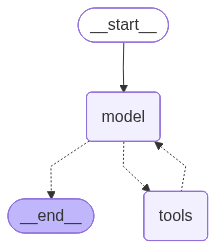

In [7]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from tools import ls, read_file, web_search, write_file

# 모델 초기화
model = ChatOpenAI(
    model="gpt-4.1",
    temperature=0.0,
)

# 파일 도구 및 웹 검색 도구 리스트 생성
tools = [ls, read_file, web_search, write_file]

# 시스템 프롬프트와 상태 스키마 지정, 에이전트 생성
agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=SYSTEM_INSTRUCTIONS,
    state_schema=FileSystemDeepAgentState,
)
agent

## 실행 및 결과 확인

In [9]:
import nest_asyncio

nest_asyncio.apply()

result = await agent.ainvoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Claude의 Agent Skills 에 대해서 한글로 설명하되, 많은 수의 리서치를 통해서 파일을 작성한 뒤 보고서 형식으로 정리해주세요.",
            }
        ],
    }
)
result

{'messages': [HumanMessage(content='Claude의 Agent Skills 에 대해서 한글로 설명하되, 많은 수의 리서치를 통해서 파일을 작성한 뒤 보고서 형식으로 정리해주세요.', additional_kwargs={}, response_metadata={}, id='e6b10c65-9560-4f00-8375-88bf05c8f611'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 979, 'total_tokens': 989, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_92419d3fe9', 'id': 'chatcmpl-CnfqfAUhwfUSMtqm4ZXxikB3LbbpV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b2b1e-6e12-7322-bc63-56447aba541f-0', tool_calls=[{'name': 'ls', 'args': {}, 'id': 'call_RwQyScta6jCCuYuDFHxIy1zi', 'type': 'tool_call'}], usage_metadata={'input_tokens': 979, 'outpu